# **Objective of This Notebook**

The purpose of this notebook is to perform an initial exploration and quality assessment of the Spotify tracks dataset prior to preprocessing and modelling. This includes understanding the dataset structure, identifying potential data quality issues, analysing feature distributions, investigating duplicate records, and exploring relationships between audio characteristics and track popularity.

Exploratory Data Analysis is used to generate initial insights into the data and guide subsequent preprocessing and modelling decisions. Particular attention is given to feature distributions, correlation patterns, genre representation, and the presence of duplicated tracks across genres.

# **1. Imports and Config**

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import requests
import os

In [2]:
import sys
sys.executable

'C:\\Users\\semoy\\AppData\\Local\\Python\\pythoncore-3.14-64\\python.exe'

### **1.1 Notebook Configuration**

In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

### **1.2 Paths**

In [4]:
# Automatically detect the project root based on the notebook location
PROJECT_ROOT = Path.cwd().parent

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "dataset.csv"
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "aggregated_df.csv"
FIGURES_PATH = PROJECT_ROOT / "outputs" / "figures" / "eda"

RAW_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT, RAW_DATA_PATH, FIGURES_PATH


(WindowsPath('C:/Users/semoy/OneDrive/Documentos/Keele University/Advanced Application of AI and ML/spotify-popularity-prediction-20260517T121628Z-3-001/spotify-popularity-prediction'),
 WindowsPath('C:/Users/semoy/OneDrive/Documentos/Keele University/Advanced Application of AI and ML/spotify-popularity-prediction-20260517T121628Z-3-001/spotify-popularity-prediction/data/raw/dataset.csv'),
 WindowsPath('C:/Users/semoy/OneDrive/Documentos/Keele University/Advanced Application of AI and ML/spotify-popularity-prediction-20260517T121628Z-3-001/spotify-popularity-prediction/outputs/figures/eda'))

### **1.3 Download Dataset**

In [5]:
#Dataset comes from HuggingFace
DATA_URL = (
    "https://huggingface.co/datasets/"
    "maharshipandya/spotify-tracks-dataset/resolve/main/dataset.csv"
)

if not RAW_DATA_PATH.exists():
    print("Downloading dataset from HuggingFace...")
    response = requests.get(DATA_URL)
    response.raise_for_status()

    with open(RAW_DATA_PATH, "wb") as f:
        f.write(response.content)

    print(f"Dataset saved to {RAW_DATA_PATH}")
else:
    print("Dataset already exists locally. Skipping download.")


Dataset already exists locally. Skipping download.


### **1.4 Load Dataset**

In [6]:
df = pd.read_csv(RAW_DATA_PATH)

print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.143,0.032,0.000,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.076,0.924,0.000,0.101,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.056,0.210,0.000,0.117,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.060,0,-18.515,1,0.036,0.905,0.000,0.132,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.443,2,-9.681,1,0.053,0.469,0.000,0.083,0.167,119.949,4,acoustic


# **2. Initial EDA**

### **2.1 Dataset description**

Column description:
*   **track_id:** The Spotify ID for the track
*   **artists:** The artists' names who performed the track. If there is more than one artist, they are separated by a ;
*   **album_name:** The album name in which the track appears
*   **track_name:** Name of the track
*   **popularity:** The popularity of a track is a value between 0 and 100, with 100 being the most popular. The popularity is calculated by algorithm and is based, in the most part, on the total number of plays the track has had and how recent those plays are. Generally speaking, songs that are being played a lot now will have a higher popularity than songs that were played a lot in the past. Duplicate tracks (e.g. the same track from a single and an album) are rated independently. Artist and album popularity is derived mathematically from track popularity.
*   **duration_ms:** The track length in milliseconds
*   **explicit:** Whether or not the track has explicit lyrics (true = yes it does; false = no it does not OR unknown)
*   **danceability:** Danceability describes how suitable a track is for dancing based on a combination of musical elements including tempo, rhythm stability, beat strength, and overall regularity. A value of 0.0 is least danceable and 1.0 is most danceable
*   **energy:** Energy is a measure from 0.0 to 1.0 and represents a perceptual measure of intensity and activity. Typically, energetic tracks feel fast, loud, and noisy. For example, death metal has high energy, while a Bach prelude scores low on the scale
*   **key:** The key the track is in. Integers map to pitches using standard Pitch Class notation. E.g. 0 = C, 1 = C♯/D♭, 2 = D, and so on. If no key was detected, the value is -1
*   **loudness:** The overall loudness of a track in decibels (dB)
*   **mode:** Mode indicates the modality (major or minor) of a track, the type of scale from which its melodic content is derived. Major is represented by 1 and minor is 0
*   **speechiness:** Speechiness detects the presence of spoken words in a track. The more exclusively speech-like the recording (e.g. talk show, audio book, poetry), the closer to 1.0 the attribute value. Values above 0.66 describe tracks that are probably made entirely of spoken words. Values between 0.33 and 0.66 describe tracks that may contain both music and speech, either in sections or layered, including such cases as rap music. Values below 0.33 most likely represent music and other non-speech-like tracks
*   **acousticness:** A confidence measure from 0.0 to 1.0 of whether the track is acoustic. 1.0 represents high confidence the track is acoustic
*   **instrumentalness:** Predicts whether a track contains no vocals. "Ooh" and "aah" sounds are treated as instrumental in this context. Rap or spoken word tracks are clearly "vocal". The closer the instrumentalness value is to 1.0, the greater likelihood the track contains no vocal content
*   **liveness:** Detects the presence of an audience in the recording. Higher liveness values represent an increased probability that the track was performed live. A value above 0.8 provides strong likelihood that the track is live
*   **valence:** A measure from 0.0 to 1.0 describing the musical positiveness conveyed by a track. Tracks with high valence sound more positive (e.g. happy, cheerful, euphoric), while tracks with low valence sound more negative (e.g. sad, depressed, angry)
*   **tempo:** The overall estimated tempo of a track in beats per minute (BPM). In musical terminology, tempo is the speed or pace of a given piece and derives directly from the average beat duration
*   **time_signature:** An estimated time signature. The time signature (meter) is a notational convention to specify how many beats are in each bar (or measure). The time signature ranges from 3 to 7 indicating time signatures of 3/4, to 7/4.
*   **track_genre:** The genre in which the track belongs






In [7]:
# Dataset overview
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

In [8]:
# Summary statistics
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000
mean,56999.500,33.239,228029.153,0.567,0.641,5.309,-8.259,0.638,0.085,0.315,0.156,0.214,0.474,122.148,3.904
std,32909.110,22.305,107297.713,0.174,0.252,3.560,5.029,0.481,0.106,0.333,0.310,0.190,0.259,29.978,0.433
min,0.000,0.000,0.000,0.000,0.000,0.000,-49.531,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,28499.750,17.000,174066.000,0.456,0.472,2.000,-10.013,0.000,0.036,0.017,0.000,0.098,0.260,99.219,4.000
50%,56999.500,35.000,212906.000,0.580,0.685,5.000,-7.004,1.000,0.049,0.169,0.000,0.132,0.464,122.017,4.000
75%,85499.250,50.000,261506.000,0.695,0.854,8.000,-5.003,1.000,0.085,0.598,0.049,0.273,0.683,140.071,4.000
max,113999.000,100.000,5237295.000,0.985,1.000,11.000,4.532,1.000,0.965,0.996,1.000,1.000,0.995,243.372,5.000


In [9]:
# Categorical overview
df.describe(include="object")

,track_id,artists,album_name,track_name,track_genre
count,114000,113999,113999,113999,114000
unique,89741,31437,46589,73608,114
top,6S3JlDAGk3uu3NtZbPnuhS,The Beatles,Alternative Christmas 2022,Run Rudolph Run,acoustic
freq,9,279,195,151,1000


## **2.2 Missing Value Analysis**

In [10]:
missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    "column": missing_values.index,
    "missing_count": missing_values.values,
    "missing_percentage": (
        missing_values.values / len(df)
    ) * 100
})

missing_df.sort_values(
    by="missing_percentage",
    ascending=False
)

,column,missing_count,missing_percentage
2,artists,1,0.001
4,track_name,1,0.001
3,album_name,1,0.001
0,Unnamed: 0,0,0.000
1,track_id,0,0.000
5,popularity,0,0.000
6,duration_ms,0,0.000
7,explicit,0,0.000
8,danceability,0,0.000
9,energy,0,0.000


Barely anything is missing, which signals that the dataset is quite clean

## **2.3 Duplicate Analysis**

In [11]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 0


In [12]:
# Duplicate track names
df["track_name"].duplicated().sum()

np.int64(40391)

40391 duplicate track names is 35% of the whole dataset, that is way more than expected. Need to investigate this further

In [13]:
df["track_id"].duplicated().sum()

np.int64(24259)

In [14]:
df.duplicated(
    subset=["track_name", "artists"]
).sum()

np.int64(32656)

24259 duplicates for track id, that is 21% duplication rate. Are tracks being repeaded across genres?

In [15]:
duplicate_tracks = df[
    df["track_id"].duplicated(keep=False)
].sort_values("track_id")

duplicate_tracks.head(20)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
15028,15028,001APMDOl3qtx1526T11n1,Pink Sweat$;Kirby,New RnB,Better,0,176320,False,0.613,0.471,1,-6.644,0,0.107,0.316,0.000,0.117,0.406,143.064,4,chill
103211,103211,001APMDOl3qtx1526T11n1,Pink Sweat$;Kirby,New RnB,Better,0,176320,False,0.613,0.471,1,-6.644,0,0.107,0.316,0.000,0.117,0.406,143.064,4,soul
85578,85578,001YQlnDSduXd5LgBd66gT,Soda Stereo,Soda Stereo (Remastered),El Tiempo Es Dinero - Remasterizado 2007,38,177266,False,0.554,0.921,2,-4.589,1,0.076,0.019,0.088,0.329,0.700,183.571,1,punk-rock
100420,100420,001YQlnDSduXd5LgBd66gT,Soda Stereo,Soda Stereo (Remastered),El Tiempo Es Dinero - Remasterizado 2007,38,177266,False,0.554,0.921,2,-4.589,1,0.076,0.019,0.088,0.329,0.700,183.571,1,ska
91801,91801,003vvx7Niy0yvhvHt4a68B,The Killers,Hot Fuss,Mr. Brightside,86,222973,False,0.352,0.911,1,-5.230,1,0.075,0.001,0.000,0.100,0.236,148.033,4,rock
3257,3257,003vvx7Niy0yvhvHt4a68B,The Killers,Hot Fuss,Mr. Brightside,86,222973,False,0.352,0.911,1,-5.230,1,0.075,0.001,0.000,0.100,0.236,148.033,4,alternative
2106,2106,003vvx7Niy0yvhvHt4a68B,The Killers,Hot Fuss,Mr. Brightside,86,222973,False,0.352,0.911,1,-5.230,1,0.075,0.001,0.000,0.100,0.236,148.033,4,alt-rock
33178,33178,004h8smbIoAkUNDJvVKwkG,Ouse;Powfu,Loners Diary,Lovemark,58,219482,True,0.808,0.331,5,-13.457,1,0.056,0.131,0.000,0.225,0.337,140.035,4,emo
94239,94239,004h8smbIoAkUNDJvVKwkG,Ouse;Powfu,Loners Diary,Lovemark,58,219482,True,0.808,0.331,5,-13.457,1,0.056,0.131,0.000,0.225,0.337,140.035,4,sad
97533,97533,006rHBBNLJMpQs8fRC2GDe,Calcinha Preta;Gusttavo Lima,CP 25 Anos (Ao Vivo em Aracaju),Agora Estou Sofrendo - Ao Vivo,47,260510,False,0.605,0.678,0,-3.257,1,0.031,0.642,0.000,0.157,0.439,125.059,4,sertanejo


In [34]:
duplicate_tracks[['track_id','track_genre']].head(10)

,track_id,track_genre
15028,001APMDOl3qtx1526T11n1,chill
103211,001APMDOl3qtx1526T11n1,soul
85578,001YQlnDSduXd5LgBd66gT,punk-rock
100420,001YQlnDSduXd5LgBd66gT,ska
91801,003vvx7Niy0yvhvHt4a68B,rock
3257,003vvx7Niy0yvhvHt4a68B,alternative
2106,003vvx7Niy0yvhvHt4a68B,alt-rock
33178,004h8smbIoAkUNDJvVKwkG,emo
94239,004h8smbIoAkUNDJvVKwkG,sad
97533,006rHBBNLJMpQs8fRC2GDe,sertanejo


**Conclusion:** looking at the above table, this datasets has duplicate rows per genre. This makes sense as a song can belong to multiple genres. We can't leave the dataset as is though, as this duplication would be a problem for the modelling phase

Here we are going to aggregate genres and consolidate tracks

In [16]:
aggregated_df = (
    df.groupby("track_id")
    .agg({
        "artists": "first",
        "album_name": "first",
        "track_name": "first",
        "popularity": "first",
        "duration_ms": "first",
        "explicit": "first",
        "danceability": "first",
        "energy": "first",
        "key": "first",
        "loudness": "first",
        "mode": "first",
        "speechiness": "first",
        "acousticness": "first",
        "instrumentalness": "first",
        "liveness": "first",
        "valence": "first",
        "tempo": "first",
        "time_signature": "first",

        # Concatenate unique genres
        "track_genre": lambda x: ", ".join(
            sorted(set(x))
        )
    })
    .reset_index()
)

Size of dataset before and after

In [17]:
print(f"Original shape: {df.shape}")
print(f"Aggregated shape: {aggregated_df.shape}")

Original shape: (114000, 21)
Aggregated shape: (89741, 20)


Now let's confirm that the only source of duplicate rows was multiple genres per track

In [18]:
aggregated_df["track_id"].duplicated().sum()

np.int64(0)

0 duplicates now. We are good to proceed

Let's inspect track_genre was aggregated correctly

In [19]:
aggregated_df[
    ["track_name", "artists", "track_genre"]
].head(10)

,track_name,artists,track_genre
0,Lolly,Rill,german
1,It's All Coming Back To Me Now (Glee Cast Vers...,Glee Cast,club
2,Böxig Leise - Pig & Dan Remix,Paul Kalkbrenner;Pig&Dan,minimal-techno
3,Teeje Week,Jordan Sandhu,hip-hop
4,Tief,Paul Kalkbrenner,minimal-techno
5,Thanksgiving Chicken,Chad Daniels,comedy
6,Better,Pink Sweat$;Kirby,"chill, soul"
7,El Tiempo Es Dinero - Remasterizado 2007,Soda Stereo,"punk-rock, ska"
8,Poor Man,Old Crow Medicine Show,bluegrass
9,Love Generation,Tokyo Ghetto Pussy,happy


## **2.4 Understanding Target Variable (Popularity)**

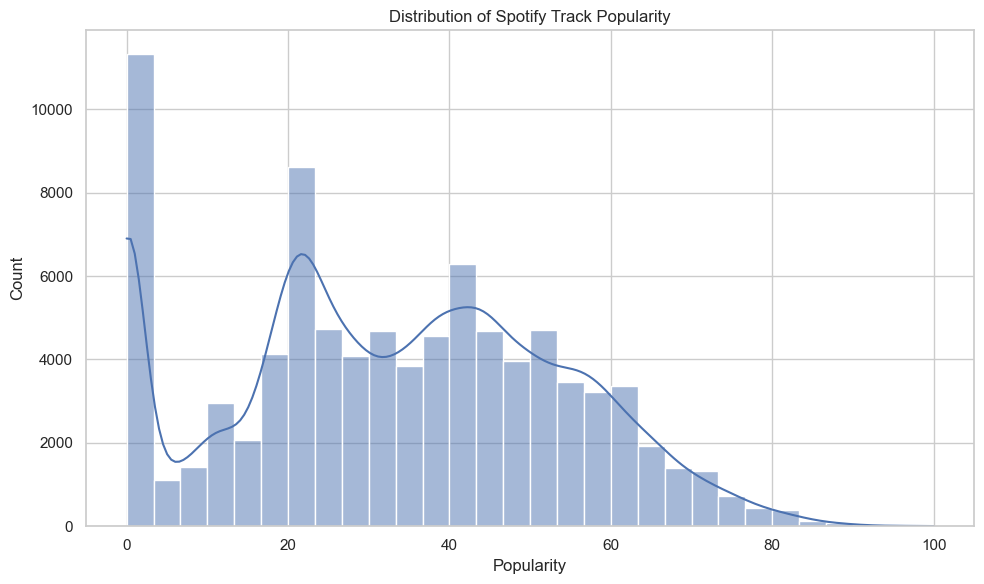

In [20]:
plt.figure(figsize=(10, 6))

sns.histplot(
    aggregated_df["popularity"],
    bins=30,
    kde=True
)

plt.title("Distribution of Spotify Track Popularity")
plt.xlabel("Popularity")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "popularity_distribution.png",
    dpi=300
)

plt.show()

## **2.5 Numerical Feature Distributions**

In [21]:
numerical_columns = aggregated_df.select_dtypes( #here we select all numerical columns
    include=["int64", "float64"]
).columns

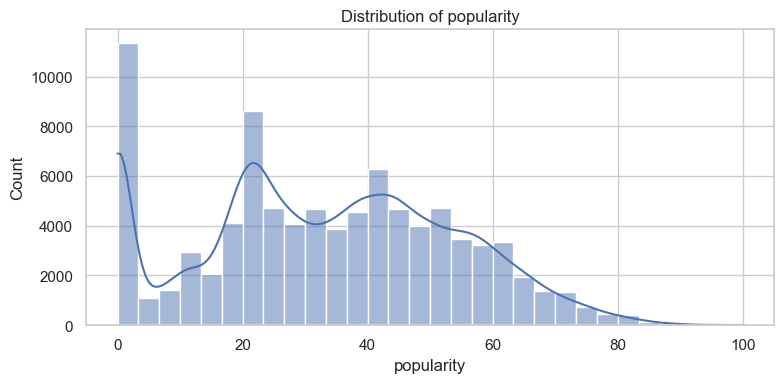

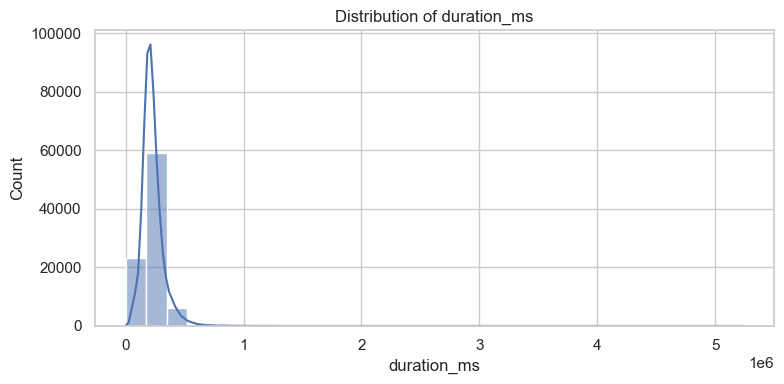

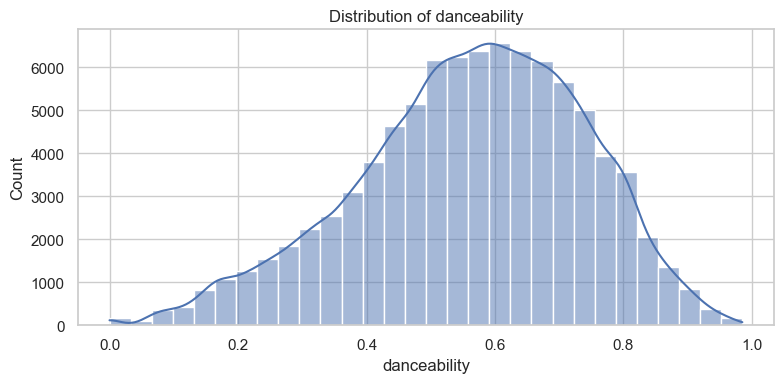

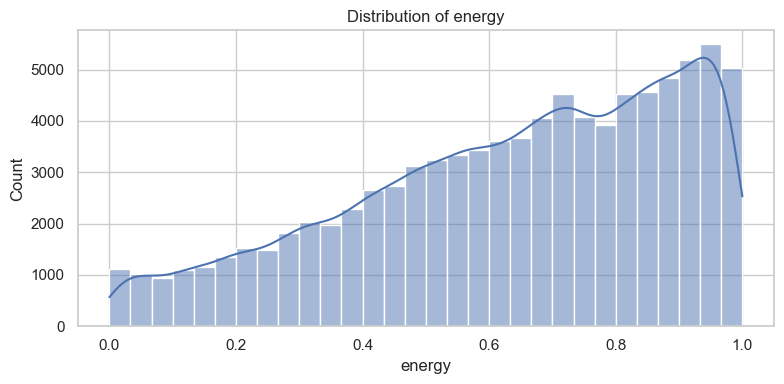

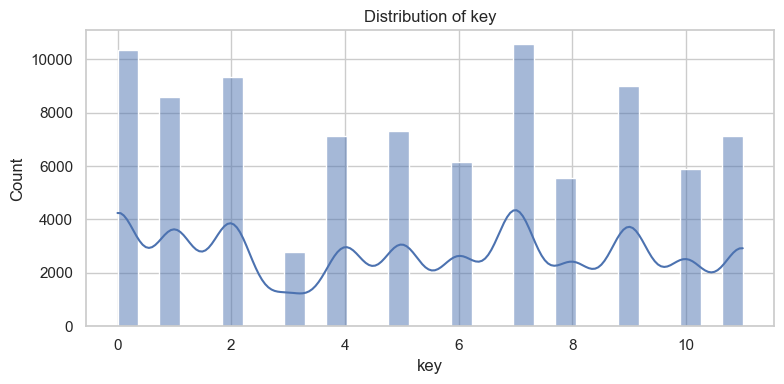

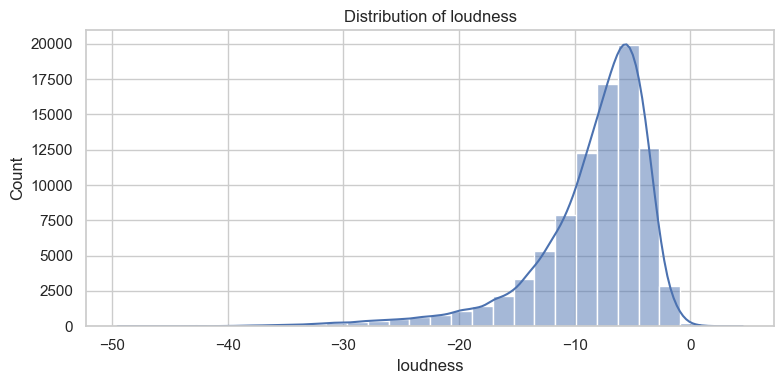

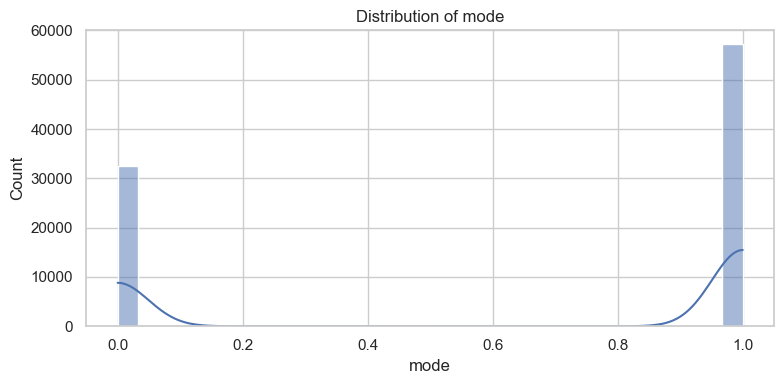

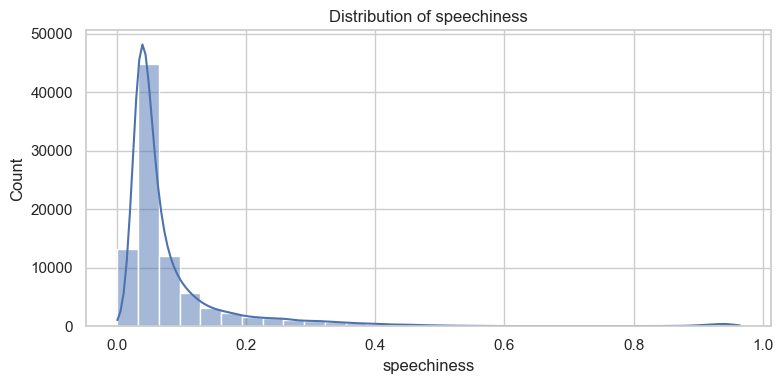

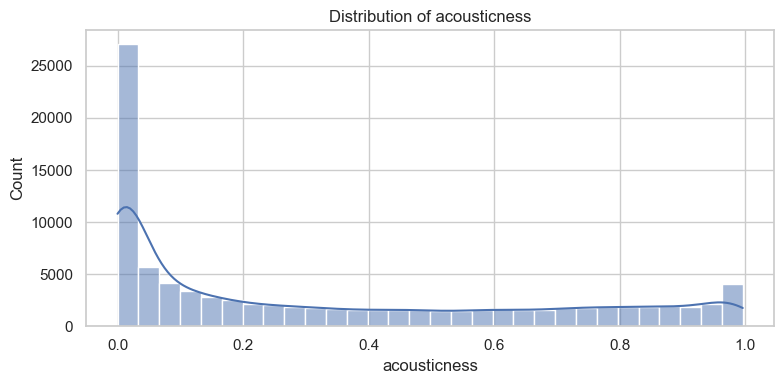

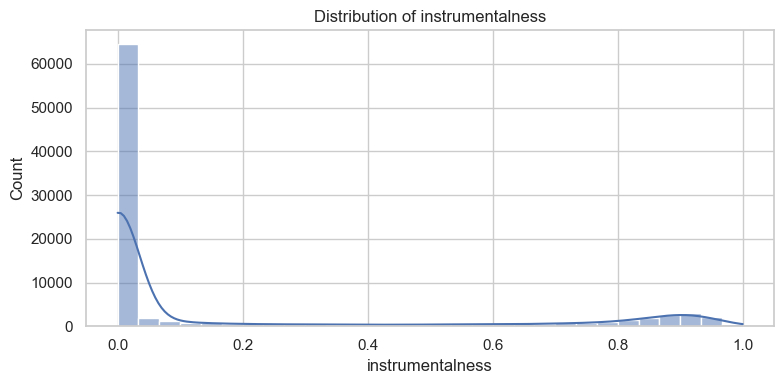

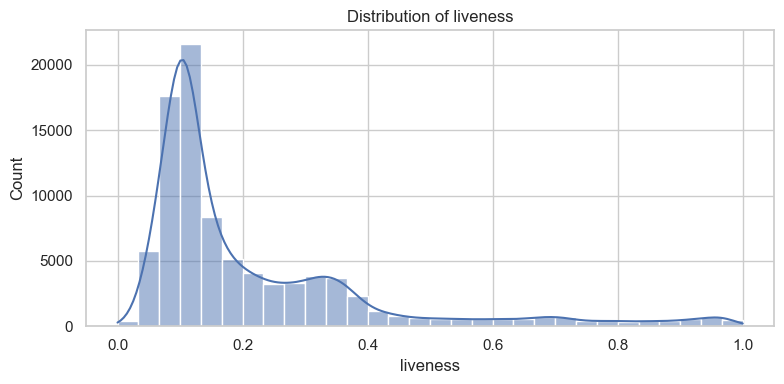

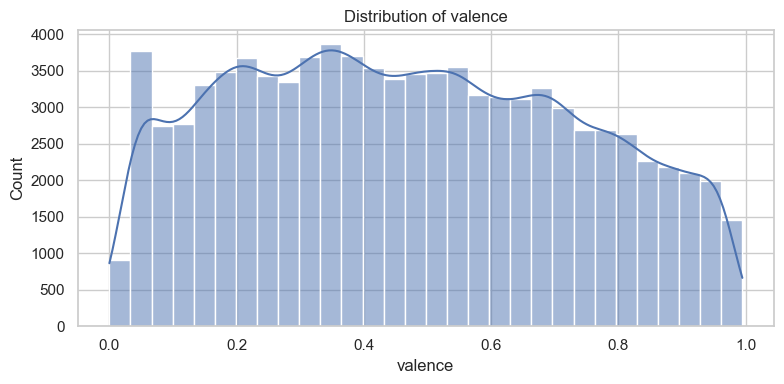

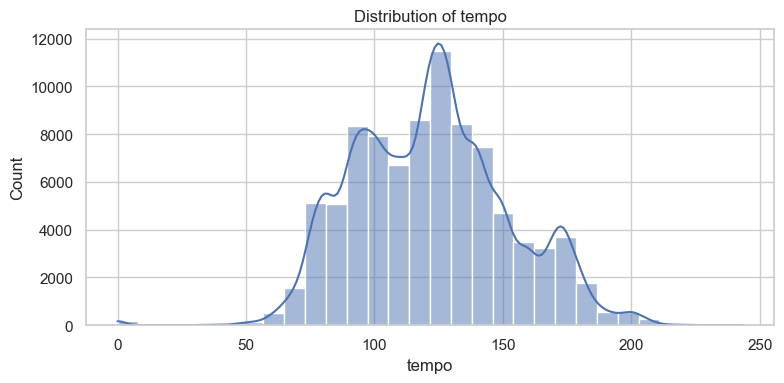

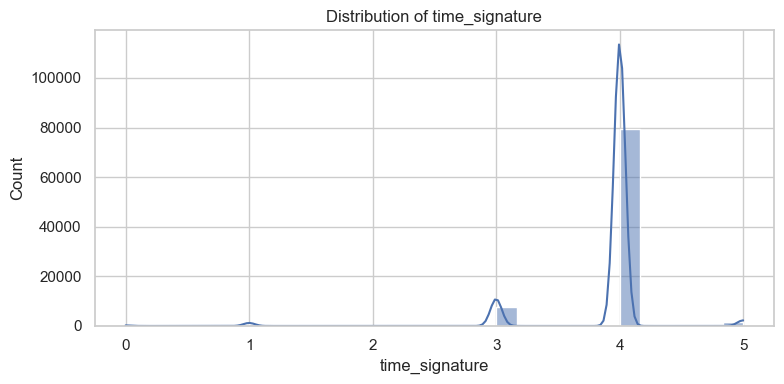

In [22]:
for column in numerical_columns:

    plt.figure(figsize=(8, 4))

    sns.histplot(
        aggregated_df[column],
        bins=30,
        kde=True
    )

    plt.title(f"Distribution of {column}")

    plt.tight_layout()

    plt.savefig(
        FIGURES_PATH / f"{column}_distribution.png",
        dpi=300
    )

    plt.show()

# **3. Correlation and Genre Analysis**

## **3.1 Correlation Matrix**

In [23]:
correlation_matrix = aggregated_df[numerical_columns].corr()

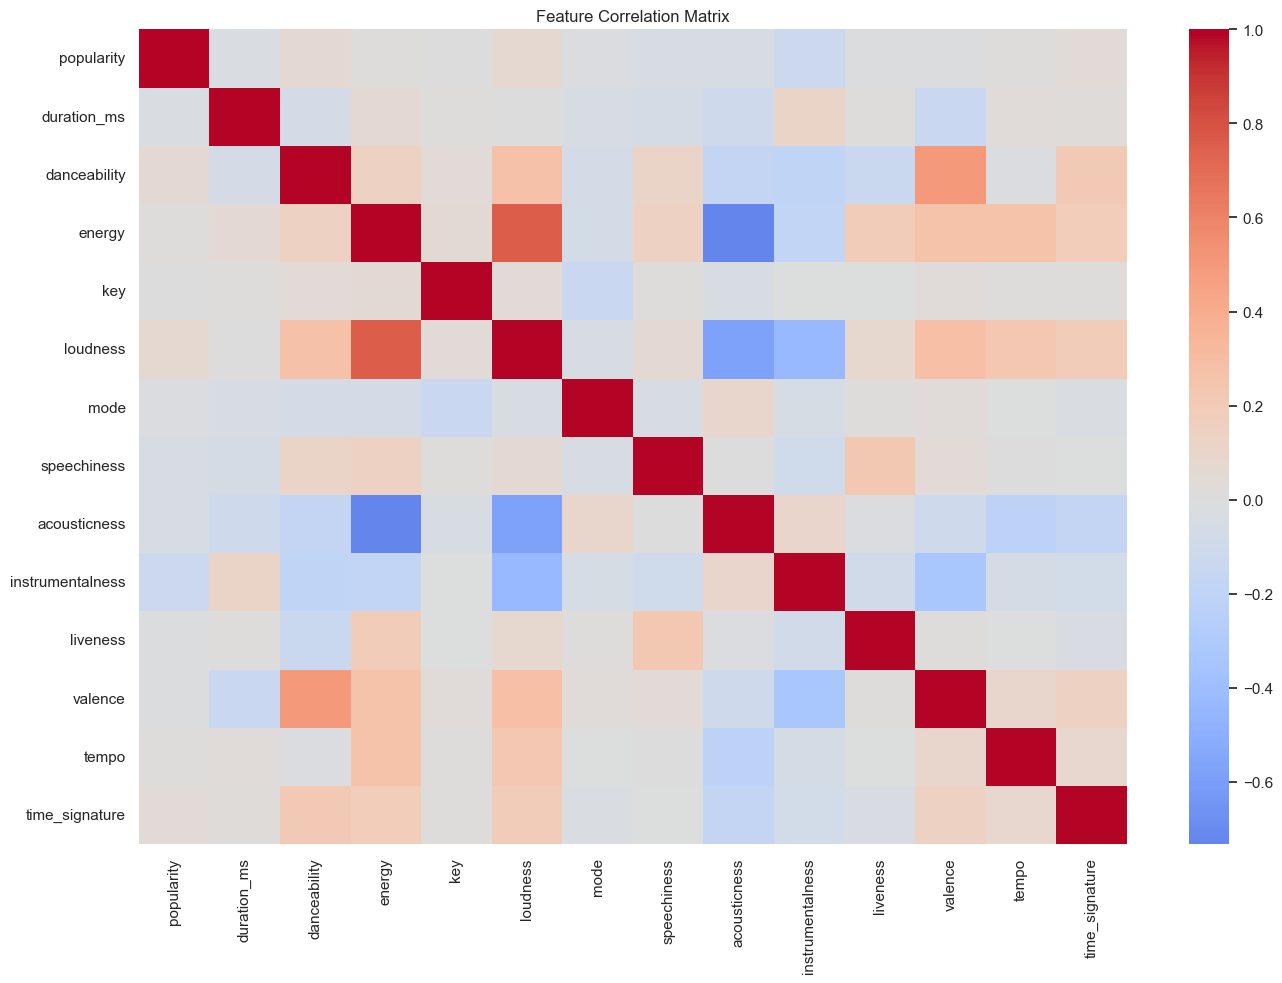

In [24]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "correlation_matrix.png",
    dpi=300
)

plt.show()

## **3.2 Correlation with Popularity**

In [25]:
popularity_corr = (
    correlation_matrix["popularity"]
    .sort_values(ascending=False)
)

popularity_corr

popularity          1.000
loudness            0.072
danceability        0.064
time_signature      0.037
energy              0.014
tempo               0.007
key                 0.003
valence            -0.012
liveness           -0.014
mode               -0.016
duration_ms        -0.023
acousticness       -0.039
speechiness        -0.047
instrumentalness   -0.127
Name: popularity, dtype: float64

## **3.3 Genre Analysis**

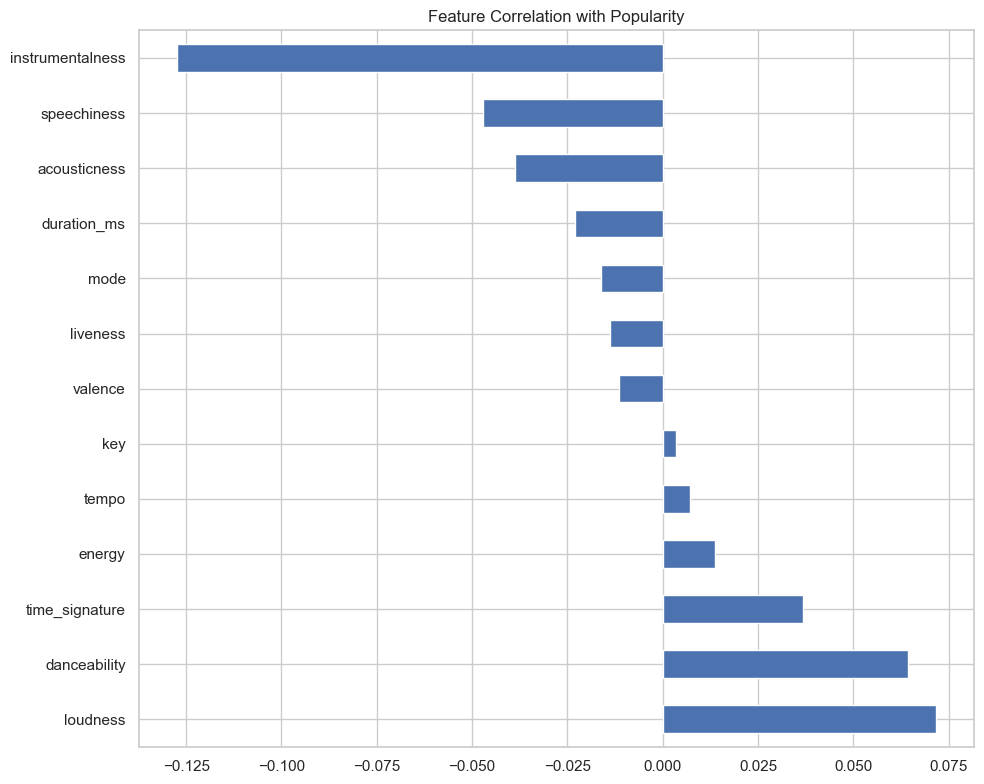

In [26]:
plt.figure(figsize=(10, 8))

popularity_corr.drop("popularity").plot(
    kind="barh"
)

plt.title("Feature Correlation with Popularity")

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "popularity_correlations.png",
    dpi=300
)

plt.show()

## **3.4 Top genres**

To measure this, we need to de-aggregate the track_genre column first

In [27]:
genre_counts = (
    aggregated_df["track_genre"]
    .str.split(", ")
    .explode()
    .value_counts()
)

top_genres = genre_counts.head(15)

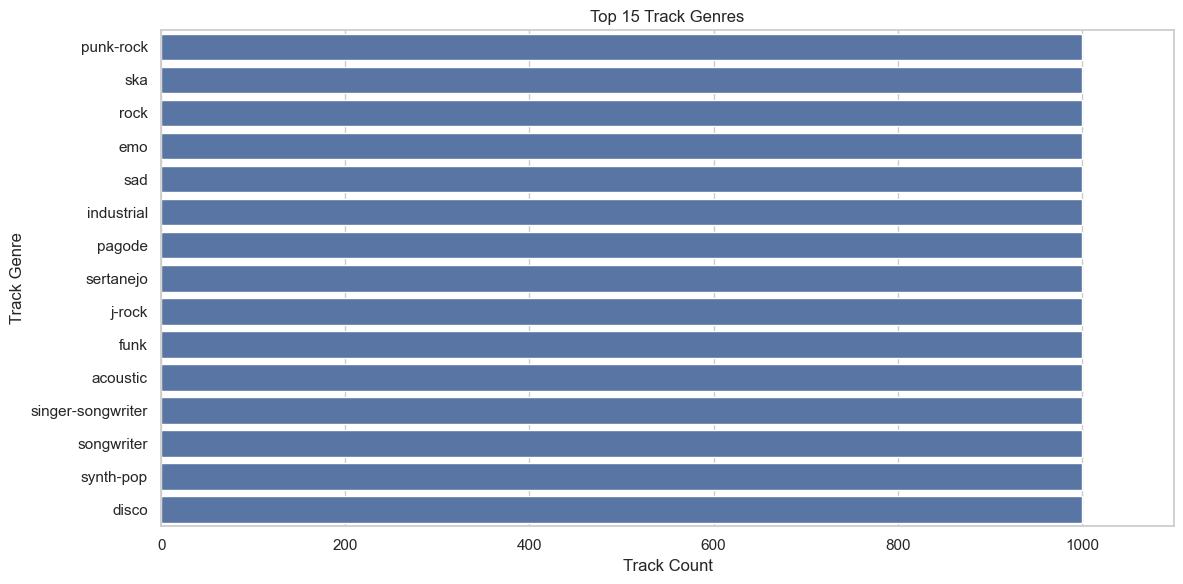

In [28]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 15 Track Genres")
plt.xlabel("Track Count")
plt.ylabel("Track Genre")

plt.xlim(0, top_genres.max() * 1.1)

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "top_genres.png",
    dpi=300
)

plt.show()

The top genre counts are identical because the dataset appears to have been intentionally balanced by genre (exactly 1000 observations per genre). Therefore, this chart is useful for understanding the dataset construction, but should not be interpreted as representing the natural distribution of Spotify tracks across genres.

Chart will be disregarded for future analyses.

# **4. Conclusions and Key Findings**

## **4.1 Dataset Structure**

Initial investigation revealed that the raw dataset was not organised around unique Spotify tracks, but rather around track-genre combinations. Multiple observations shared identical track_id values and audio features while differing only in genre labels. This structure introduced risks of duplicated observations and potential issues for the training phase.

To address this issue, duplicated tracks were consolidated into a single observation per unique track_id, while genre labels were aggregated into a single field. This transformation produced a cleaner and more methodologically valid dataset for downstream analysis and modelling, without the need to drop the track_genre column entirely

Also, dataset seems to be constructed as to keep musical genres count balanced, therefore there is no 'top genre' by appearance.

## **4.2 Data Quality**

The dataset exhibited generally high data quality, with only a negligible number of missing values across categorical fields and no fully duplicated rows. Audio features displayed coherent and interpretable relationships, suggesting that the variables capture meaningful musical characteristics.

However, the genre distribution appeared artificially balanced, with many genres containing nearly identical observation counts. This suggests that the dataset was intentionally sampled or expanded by genre during its construction rather than representing a naturally distributed Spotify population

## **4.3 Exploratory Analysis Findings**

The popularity target variable exhibited a strongly imbalanced distribution, with a large concentration of tracks near very low popularity values and relatively few highly popular songs. This suggests that predicting popularity may be challenging due to uneven target representation.

Several meaningful relationships between audio features were found:
*   Loud and energetic songs tend to be strongly associated
*   Danceable tracks tend to exhibit more positive emotional characteristics (vhigh alence)
*   Acoustic tracks tend to be less energetic and quieter.


Correlation analysis revealed that most individual audio features exhibit relatively weak linear relationships with popularity. The strongest positive correlations were observed for **loudness**, **danceability** and **time_signature**

Meanwhile, **instrumentalness** showed the strongest negative relationship with popularity, suggesting that instrumental tracks tend to achieve lower mainstream popularity levels.

Save aggregated_df for Notebook #2

In [29]:
aggregated_df.to_csv(PROCESSED_DATA_PATH, index=False)

print(f"Aggregated dataset saved to: {PROCESSED_DATA_PATH}")


Aggregated dataset saved to: C:\Users\semoy\OneDrive\Documentos\Keele University\Advanced Application of AI and ML\spotify-popularity-prediction-20260517T121628Z-3-001\spotify-popularity-prediction\data\processed\aggregated_df.csv


Quick test to make sure everything saved in the correct folders...

In [30]:
print("Project root:", PROJECT_ROOT)
print("Raw data path:", RAW_DATA_PATH)
print("Figures path:", FIGURES_PATH)
print("Figures path:", PROCESSED_DATA_PATH)

Project root: C:\Users\semoy\OneDrive\Documentos\Keele University\Advanced Application of AI and ML\spotify-popularity-prediction-20260517T121628Z-3-001\spotify-popularity-prediction
Raw data path: C:\Users\semoy\OneDrive\Documentos\Keele University\Advanced Application of AI and ML\spotify-popularity-prediction-20260517T121628Z-3-001\spotify-popularity-prediction\data\raw\dataset.csv
Figures path: C:\Users\semoy\OneDrive\Documentos\Keele University\Advanced Application of AI and ML\spotify-popularity-prediction-20260517T121628Z-3-001\spotify-popularity-prediction\outputs\figures\eda
Figures path: C:\Users\semoy\OneDrive\Documentos\Keele University\Advanced Application of AI and ML\spotify-popularity-prediction-20260517T121628Z-3-001\spotify-popularity-prediction\data\processed\aggregated_df.csv
